# **Hands-on 〜 Optimization for Traffic Congestion Reduction 〜**

## Introduction
This hands-on walks through building a real, working application end to end, using a flagship application of quantum annealing: reducing traffic congestion by choosing good routes. It's the problem made famous by the Volkswagen study — several cars each have a few candidate routes, and the goal is to pick routes across all of them so the cars don't crowd onto the same roads.

---

## Chapter 1　Problem Setup ― What Are We Optimizing?

### Why We Tackle This Problem

Traffic congestion is a major issue for cities around the world. It does not just increase travel time — it also wastes fuel, raises emissions, and delays logistics, affecting both the economy and the environment.

One cause of congestion is that **too many cars end up on the same road**.

So we aim to avoid this concentration and find a combination of routes that does not get congested.

### How We Frame the Problem

Let us organize this into a form a computer can solve. We set up the situation as follows.

- Several cars each travel from a **start point → destination**
- Each car is given **several candidate route patterns**, and chooses **exactly one** of them

In other words: which route should we assign to which car so that the whole system is as uncongested as possible?

### Setting Up the Variables
To solve this as an optimization problem, we represent "which route is chosen" with 0/1 variables.

- Car $i$ chooses its $k$-th route … $x_{ik} = 1$
- Does not choose it … $x_{ik} = 0$

For each car $i$, there are $K$ candidate routes, $k = 1, \ldots, K$.

In the next chapter, we use these variables to **write down the degree of congestion as a cost function**, and search for the combination that minimizes it.

## Chapter 2　Formulating the Cost Function

Let us first look at the finished form we are heading toward. The cost function is:

$$E(x) = \sum_{e} \left( \sum_{i=1}^{N}\sum_{k=1}^{K} C_{eik}\, x_{ik} - \frac{1}{2} \right)^2 + \lambda \sum_{i=1}^{N} \left( \sum_{k=1}^{K} x_{ik} - 1 \right)^2$$

### First Term ― Congestion Cost

First, we use $C_{eik}$ to indicate whether car $i$'s route $k$ passes through road $e$ (1 if it does, 0 if not). Then the number of cars passing through road $e$ can be counted as follows.

$$C_e = \sum_{i=1}^{N}\sum_{k=1}^{K} C_{eik}\, x_{ik}$$

- No one passes ($C_e = 0$) … not congestion
- Only one car passes ($C_e = 1$) … also not congestion
- Two, three, or more gather ($C_e \geq 2$) … congestion starts here

To express this shape — "0 cars and 1 car are the same, 2 or more gets worse" — directly as a formula, we assign each road the cost

$$\left( C_e - \frac{1}{2} \right)^2$$

Since it grows for 2 or more, minimizing it scatters the cars onto different roads.

Summing this over all roads gives the first term.

### Second Term ― the "One per Car" Constraint

Now we turn the rule "each car chooses exactly one route" into a formula. For car $i$, summing the number of chosen routes must equal exactly one, so

$$\sum_{k=1}^{K} x_{ik} = 1$$

This is the **equality constraint**. So that deviating from it (choosing 0 routes, or 2 or more) incurs a penalty, we use the **penalty method** to build the following term.

$$\lambda \sum_{i=1}^{N} \left( \sum_{k=1}^{K} x_{ik} - 1 \right)^2$$

### Summary

The first term reduces congestion, and the second term enforces the rule ── this is the cost function for our problem.

---

## Chapter 3　Getting Ready ― Libraries and Map Data

### Libraries We Use

- **osmnx** … handles map and road data
- **networkx** … works with graphs

We install osmnx below. Its dependencies — including networkx, numpy, and matplotlib — come along with it.

In [ ]:
!pip install osmnx
!pip install dwave-samplers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 909.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 14.3 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import osmnx as ox
import networkx as nx
from dwave.samplers import SimulatedAnnealingSampler

We specify the area we want by the **latitude and longitude** of its north, south, east, and west edges. Here we use the area around Singapore Management University as an example.

In [ ]:
#Around Singapore Management University
mr = {
    'north': 1.315000, 'south': 1.295000,
    'east': 103.855000, 'west': 103.828000
}

We load the road network within that box.

In [ ]:
G = ox.graph_from_bbox(
    (mr['west'], mr['south'], mr['east'], mr['north']),
    network_type='drive',
)

Display it with `plot_graph` and check that we captured the intended location.

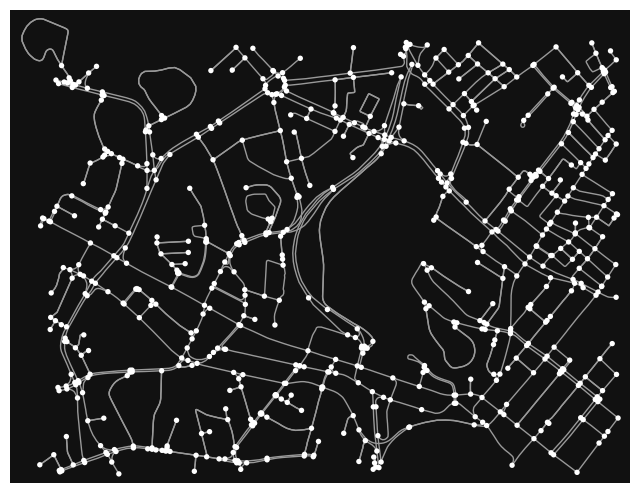

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
ox.plot_graph(G)

Is the intended location drawn as expected?

## Chapter 4　Generating Route Patterns

### Deciding Start Points and Destinations

First we decide the number of cars and candidate routes, then prepare start points paired with reachable destinations.

In [ ]:
car_n = 10       # number of cars
num_route = 3    # number of routes per car
N = car_n * num_route

In [ ]:
node_list = []
for key in G.nodes(data=False):
    node_list.append(key)

node_list_perm = np.random.permutation(node_list)

`node_list` holds the point IDs as a list. We shuffle this list into a random order with `random.permutation` (random permutation).

From the shuffled points, we choose each car's start point and pair it with a destination that is **connected by roads**. Since a disconnected point cannot form a route, we check connectivity with networkx's `nx.has_path()` while choosing.

> **If you hit an error:** you may get an `IndexError` here. It happens when one of the chosen start points isn't well connected to other points, so no reachable destination is found. If that happens, **re-run the previous cell, then run this one again, or reduce the number of cars**.

In [ ]:
start_list = node_list_perm[0:car_n]   # use the front as start points

# for each start point, pick one reachable destination
n = 0
end_list = []
while len(end_list) < car_n:
    k = len(end_list)
    cand = node_list_perm[car_n+k+n]
    if nx.has_path(G, start_list[k], cand):
        end_list.append(cand)
    else:
        n = n + 1

### Creating Route Patterns

`nx.shortest_path()` gives the shortest route, but only one route.

So we use a trick: inflate the distance of roads already used to make them "less attractive," then find the shortest route again. A different route emerges. Repeating this, we store the candidate routes in `route_list`.

In [ ]:
def penalty(G,route,pen):
    for k in range(len(route)-1):
        i = route[k]
        j = route[k+1]
        G[i][j][0]['length'] += pen
    return G

In [ ]:
route_list = []
for k in range(car_n):
    start_key = start_list[k]
    end_key = end_list[k]
    shortest_route1 = nx.shortest_path(G, start_key, end_key, 'length')
    route_list.append(shortest_route1)
    G = penalty(G,shortest_route1,200)

    shortest_route2 = nx.shortest_path(G, start_key, end_key, 'length')
    route_list.append(shortest_route2)
    G = penalty(G,shortest_route2,200)

    shortest_route3 = nx.shortest_path(G, start_key, end_key, 'length')
    route_list.append(shortest_route3)
    G = penalty(G,shortest_route3,200)

    # restore the inflated distances
    G = penalty(G,shortest_route1,-200)
    G = penalty(G,shortest_route2,-200)
    G = penalty(G,shortest_route3,-200)

### Checking the Generated Routes

`route_list` now contains 3 routes × each car. Let us draw them all together on the map.

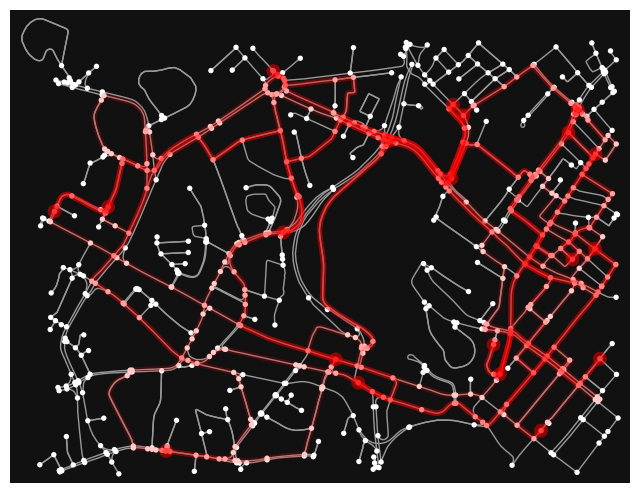

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
ox.plot_graph_routes(G, route_list, route_alpha=0.2)

Many red routes should now appear on the map.
To draw routes one at a time, select one with `route_list[k]` and use osmnx's `plot_graph_route()`.

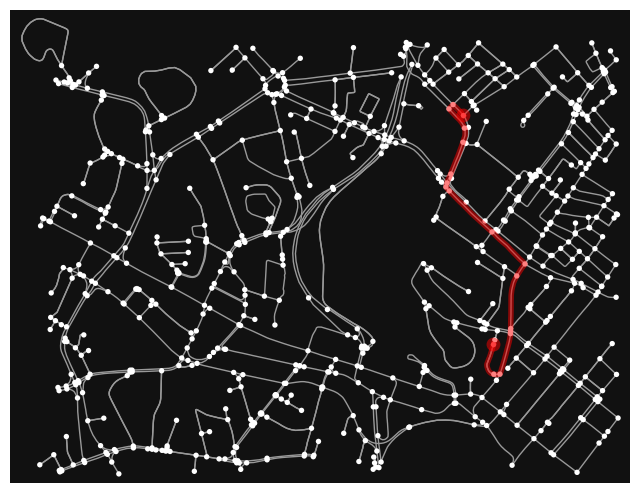

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
ox.plot_graph_route(G, route_list[0])

Comparing two different routes of the same car (`route_list[0]` and `[1]`), you can see that the start and destination are shared, and only the path in between differs.

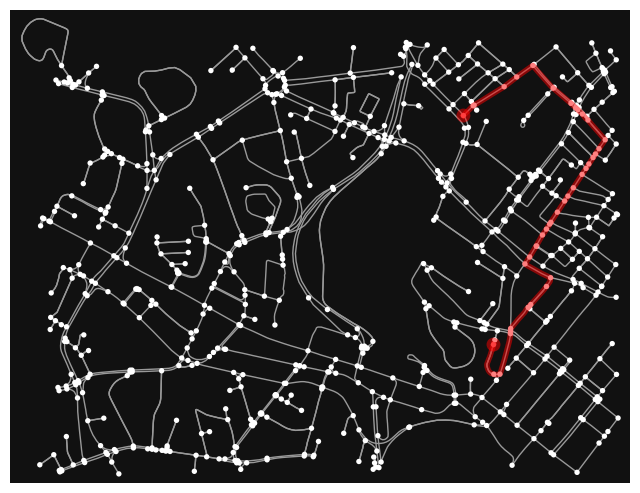

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
ox.plot_graph_route(G, route_list[1])

## Chapter 5　Building the QUBO Matrix

So far we have written the variables as $x_{ik}$ with two indices, but in the implementation a single index is often easier to handle. So we assign consecutive numbers, $K$ per car, and merge them into a single serial index $m$.

$$m = k + K \cdot i \quad\Longrightarrow\quad x_{ik} = x_m$$

Here $K$ is the number of routes per car (`num_route` in the code). In the code below, we use this $m$ as the matrix index (`m = k + i*num_route` corresponds to this formula).

### Step 1: Building $C_{em}$

$C_{em}$ was the matrix indicating "whether route $m$ passes through road $e$ (1 if it passes, 0 if not)."

However, within the generated routes, a road is only represented as a **pair of points** `(route[l], route[l+1])`, and there is no row number $e$ for the matrix. So first, we build a dictionary `edge_dict` that assigns serial numbers $0, 1, 2, \ldots$ to the roads that appear.

In [ ]:
edge_dict = {}
k = 0
for route in route_list:
  for l in range(len(route)-1):
    e = (route[l],route[l+1])
    if e not in edge_dict.keys():
      edge_dict[e] = k
      k = k + 1

`edge_dict` is a lookup table for "road (a pair of two points) → serial number $e$." Tracing through all routes, it assigns numbers $0, 1, 2, \ldots$ in order to each road the first time it appears.

Printing out `edge_dict` will help you understand it better.

Next, using this, we build the matrix $C_{em}$. Rows are roads $e$, columns are routes $m$, and we place a 1 where "route $m$ passes through road $e$."

The construction is simple: prepare a matrix of all zeros, look at each road a route follows one by one, and write a 1 at that position.

In [ ]:
C = np.zeros(N*len(edge_dict)).reshape(len(edge_dict),N)
for i in range(car_n):
  for k in range(num_route):
    m = k+i*num_route
    p = route_list[m]
    for l in range(len(p)-1):
      e = edge_dict[(p[l],p[l+1])]
      C[e,m] = 1

### Step 2: First Term (Congestion Cost) → Matrix $Q_1$

We turn the first term from Chapter 2,

$$\sum_e \left( \sum_m C_{em} x_m - \frac{1}{2} \right)^2$$

into a matrix. Writing the number of cars on a road as $C_e = \sum_m C_{em} x_m$ and expanding,

$$\sum_e \left( C_e - \frac{1}{2} \right)^2 = \sum_e C_e^2 \; - \; \sum_e C_e \; + \; \text{const}$$

**Quadratic term**

$$\sum_e C_e^2 = \sum_{m,n} \left( \sum_e C_{em} C_{en} \right) x_m x_n$$

expands as above, and the sum over $e$ is exactly the inner product $C^\top C$ of the matrix $C$.

**Linear term**

$$- \sum_e C_e = - \sum_m \left( \sum_e C_{em} \right) x_m$$

For binary variables, $x_m = x_m^2$ holds, so this term can be placed on the diagonal. Concretely, we subtract the number of roads route $m$ passes through (the sum of column $m$ of $C$) from the $(m,m)$ entry of $Q_1$.

Combining these two, $Q_1$ is built as follows.

In [ ]:
# Quadratic term: sum_e C_e^2 -> C^T C
Q1 = np.dot(C.T, C)

# Linear term: place -sum_e C_e on the diagonal (since x_m = x_m^2)
col_sum = C.sum(axis=0)
for m in range(N):
    Q1[m, m] = Q1[m, m] - col_sum[m]

### Step 3: Second Term (Constraint) → Matrix $Q_2$
The second term was the constraint "each car chooses exactly one route."

Expanding it out term by term,
\begin{equation}
\lambda \sum_{i=1}^N \left( \sum_{k=1}^K x_{ik} -1 \right)^2 = \lambda \sum_{i=1}^N \sum_{k=1}^K \sum_{l=1}^K x_{ik}  x_{il} -2 \lambda\sum_{i=1}^N\sum_{k=1}^K x_{ik}+ \lambda KN
\end{equation}
The final constant can be left aside, and we focus only on the parts multiplied by $x_{ik}$.

In [ ]:
Q2 = np.zeros(N**2).reshape(N,N)

for i in range(car_n):
  for k in range(num_route):
    for l in range(num_route):
      m1 = k + i*num_route
      m2 = l + i*num_route
      Q2[m1,m2] = Q2[m1,m2] + 1.0
      if m1 == m2:
        Q2[m1,m2] = Q2[m1,m2] -2.0

### Step 4: Combining the Two into Dictionary Form
Adding $Q_1$ and $Q_2$ with weight $\lambda$ completes the QUBO matrix.

Note that as the number of cars or routes grows, the matrix becomes huge, but most of its entries are $0$. Since it is enough to send only the nonzero entries to the machine, we convert it into dictionary (dict) form.

In [ ]:
lam = 100.0
Q = Q1 + lam*Q2

Qdict = {}
for m in range(N):
  for n in range(N):
    if Q[m,n] != 0.0:
      Qdict[m,n] = Q[m,n]

We are now ready to submit to the quantum annealer!

---

## Chapter 6　Submitting to the Quantum Annealer

The hardest preparation is done. From here, we just send the QUBO and receive the result.

In [ ]:
# use D-Wave's simulated annealing sampler
sampler = SimulatedAnnealingSampler()

Let's send the `Qdict` we prepared.

In [ ]:
sampleset = sampler.sample_qubo(Qdict, num_reads=10)
print(sampleset.record)

[([0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1], -898., 1)
 ([0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0], -876., 1)
 ([0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0], -894., 1)
 ([0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1], -906., 1)
 ([0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0], -846., 1)
 ([0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1], -892., 1)
 ([0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1], -888., 1)
 ([0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0], -896., 1)
 ([0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1], -902., 1)
 ([0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0

From the results, we pick the one with the **lowest energy**.

In [ ]:
energies = sampleset.record['energy']
min_idx = np.argmin(energies)
answer = sampleset.record[min_idx][0]

print(answer)

[0 0 1 0 0 1 1 0 0 0 0 1 1 0 0 1 0 0 0 0 1 0 0 1 1 0 0 0 0 1]


### Extracting the Chosen Routes

`answer` is a sequence of 0s and 1s, with a **1 at the position of each chosen route**. For each car, exactly one of its $K=3$ routes should be 1.

We can find which positions are 1 with `np.where()` (a function that returns the positions where a condition holds; the trailing `[0]` extracts just the indices). From the obtained indices $m$, we collect the corresponding routes `route_list[m]`.

In [ ]:
answer_routes = []
answer_list = np.where(answer == 1)[0]
for m in answer_list:
  print(m)
  answer_routes.append(route_list[m])

2
5
6
11
12
15
20
23
24
29


### Drawing on the Map to Check

Finally, we overlay the chosen routes on the map.

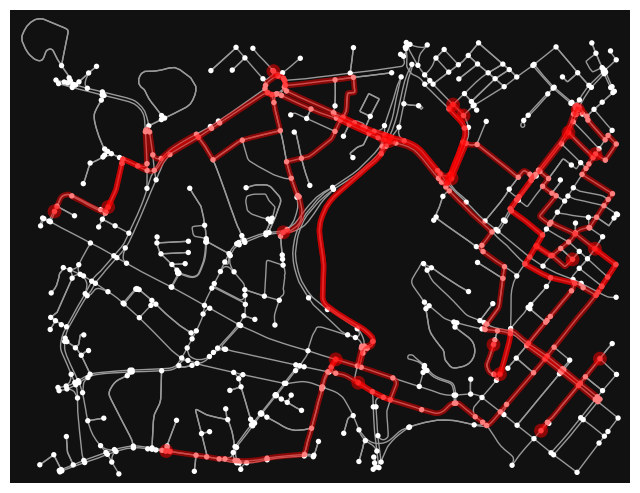

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
ox.plot_graph_routes(G, answer_routes, route_alpha= 0.5)

It is a success if each car's route is drawn **spread out**, not concentrated on the same road. The quantum annealer chose a combination of routes that avoids congestion.

Well done. From coming up with the cost function, to gathering data, converting to QUBO ── you have experienced the whole flow.

One more thing: here we judged success just by eye, but real research evaluates the solution quantitatively. For example, you might measure the **number of congested roads** (how many roads carry more than one car) or the **degree of concentration** (how heavily cars pile onto particular roads), and use those to check numerically how much the congestion improved.